In [1]:
import numpy as np
import dask , dask.distributed
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import cmocean.cm as cmo
import warnings
warnings.simplefilter('ignore')
import dask_jobqueue
from astropy.convolution import Box2DKernel, convolve
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
import matplotlib.colors as colors
import pandas as pd
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

##custom functions
from fix_grid import fix_grid 

from matplotlib.colors import ListedColormap
import matplotlib

import sys
import os

sys.path.append(os.path.abspath('../filtering/'))
from filter import filtering_median

In [2]:
# try filtering for only agulhas region to obtain a correlation map

In [3]:
pathf='/gxfs_work/geomar/smomw577/mesoscale_eddies/BOX_filtered/0181-0190/'
dsa=xr.open_dataset(pathf+'3x3box_median_anomaly_monthly_0181-0190_all.nc')
ds=xr.open_dataset('/gxfs_work/geomar/smomw577/mesoscale_eddies/MOM5_concat/0181/MOM5_daily.nc')

In [4]:
# now for daily data:
ds=ds.sel(xt_ocean=slice(-10,60)).sel(yt_ocean=slice(-55,-20))

In [4]:
daily=filtering_median(ds, size=30)

In [10]:
daily.to_netcdf('daily_filtered.nc')

In [5]:
daily=xr.open_dataset('daily_filtered.nc')

In [ ]:
daily_ano=(ds-daily).sel(xt_ocean=slice(0,50), yt_ocean=slice(-45,-30))

In [ ]:
daily_ano.to_netcdf('daily_anomaly.nc')

In [6]:
daily_ano=xr.open_dataset('daily_anomaly.nc')

In [7]:
##now plot exemplary 
agday0m=dsa.sel(xt_ocean=slice(0,50), yt_ocean=slice(-45,-30)).isel(time=0)
agday0=daily_ano.isel(time=0)

In [8]:
monthly_corr=xr.corr(dsa.sel(xt_ocean=slice(0,50), yt_ocean=slice(-45,-30)).dic_stf, dsa.sel(xt_ocean=slice(0,50), yt_ocean=slice(-45,-30)).o2_stf, dim='time')

In [9]:
daily_corr=xr.corr(daily_ano.dic_stf, daily_ano.o2_stf, dim='time')

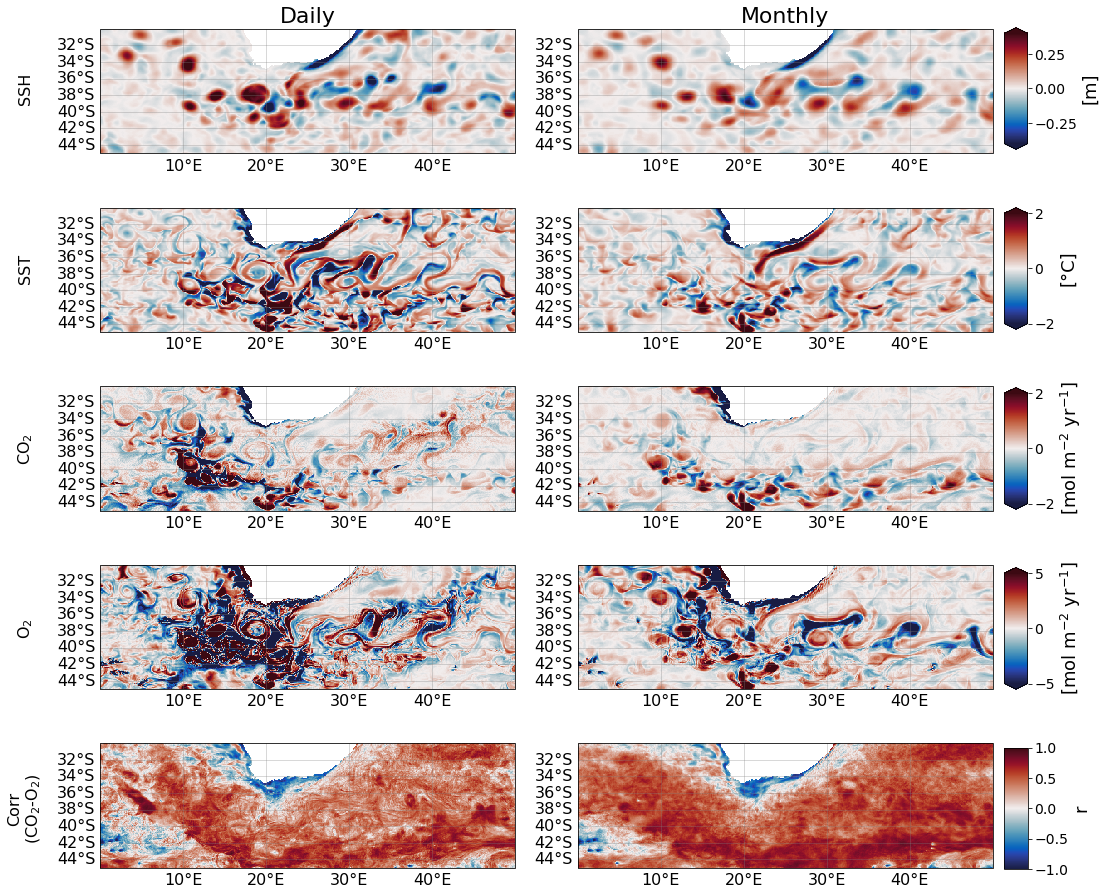

In [10]:
fig, axs= plt.subplots(nrows=5, ncols=2 , figsize=(16,16),subplot_kw={'projection': ccrs.PlateCarree()})
axs=axs.flatten()

plt.rcParams.update({
    "font.size":16,
    "axes.titlesize":22,
    "axes.labelsize":18,
    "xtick.labelsize":14,
    "ytick.labelsize":14
})


agday0.SSH.plot(ax=axs[0], vmin=-0.4, vmax=0.4, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)
agday0m.SSH.plot(ax=axs[1],vmin=-0.4, vmax=0.4, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)
agday0.SST.plot(ax=axs[2], vmin=-2, vmax=2, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)
agday0m.SST.plot(ax=axs[3],vmin=-2, vmax=2, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False);
agday0.dic_stf.plot(ax=axs[4],vmin=-2, vmax=2, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)
agday0m.dic_stf.plot(ax=axs[5],vmin=-2, vmax=2, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)
agday0.o2_stf.plot(ax=axs[6],vmin=-5, vmax=5, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)
agday0m.o2_stf.plot(ax=axs[7],vmin=-5, vmax=5, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)

daily_corr.plot(ax=axs[8],vmin=-1, vmax=1, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False);
monthly_corr.plot(ax=axs[9],vmin=-1, vmax=1, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False);

for i in range(10):
    gl = axs[i].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.3)
    gl.xlabels_top = False
    gl.ylabels_right = False

axs[0].set_title('Daily');
axs[1].set_title('Monthly');
for i in range (2,10):
    axs[i].set_title('');

#cax_ssh = fig.add_axes([0.92, 0.76, 0.02, 0.14])  # [left, bottom, width, height]
#
#fig.colorbar(
#    axs[0].collections[0],
#    cax=cax_ssh,
#    orientation='vertical',
#    label='SSH [m]', extend='both'
#)
#
## SST colorbar (right column)
#cax_sst = fig.add_axes([0.92, 0.60, 0.02, 0.14])
#
#fig.colorbar(
#    axs[1].collections[0],
#    cax=cax_sst,
#    orientation='vertical',
#    label='SST [°C]', extend='both'
#)
#
#cax_sst = fig.add_axes([0.92, 0.44, 0.02, 0.14])
#
#fig.colorbar(
#    axs[2].collections[0],
#    cax=cax_sst,
#    orientation='vertical',
#    label='CO$_2$ [mol m$^{-2}$ yr$^{-1}$]', extend='both'
#)
#
#cax_sst = fig.add_axes([0.92, 0.28, 0.02, 0.14])
#
#fig.colorbar(
#    axs[3].collections[0],
#    cax=cax_sst,
#    orientation='vertical',
#    label='O$_2$ [mol m$^{-2}$ yr$^{-1}$]', extend='both'
#)
#
#cax_sst = fig.add_axes([0.92, 0.12, 0.02, 0.14])

#fig.colorbar(
#    axs[4].collections[0],
#    cax=cax_sst,
#    orientation='vertical',
#    label='r (CO$_2$-O$_2$)', extend='both'

labels = [
    "SSH",
    "SST",
    "CO$_2$",
    "O$_2$",
    "Corr\n(CO$_2$-O$_2$)"
]

units=[
    "[m]", "[°C]", "[mol m$^{-2}$ yr$^{-1}$]", "[mol m$^{-2}$ yr$^{-1}$]", "r"
]

for i in range(10):
    if i%2==1:
        pos = axs[i].get_position()
        
        cax = fig.add_axes([
            pos.x1 + 0.01,   # small gap to the right
            pos.y0,          # exact bottom of subplot
            0.02,            # width of colorbar
            pos.height       # EXACT same height as subplot
        ])

        if i!=9:
            extend='both'
        elif i==9:
            extend='neither'
        
        fig.colorbar(
            axs[i].collections[0],
            cax=cax,
            orientation='vertical',
            extend=extend, label=f"{units[(i-1)//2]}"
        )


# --- Add vertical row labels ---
row_centers = [0.83, 0.67, 0.51, 0.35, 0.19]



for i in range(10):
    if i%2==0:
        pos = axs[i].get_position()  # get axis position
        y_center = pos.y0 + pos.height / 2
        
        fig.text(
            0.06,
            y_center,
            labels[i//2],
            va='center',
            ha='center',
            rotation=90,
            fontsize=16
        )

# Layout tweak
plt.subplots_adjust(hspace=0.15, wspace=0.15)
plt.savefig('/gxfs_home/geomar/smomw577/plots/Boxcar/0181-0190/monthly_vs_daily_snapshot_SI.png', bbox_inches="tight", dpi=300)